In [1]:
import numpy as np
import pandas as pd

In [3]:
bills = pd.read_csv("bills_cleaned_and_labeled2.csv")
bills

,title,status,proposal_date,categories,party_cleaned
0,ร่างพระราชบัญญัติชั่วโมงปฏิบัติงานด้านสาธารณสุ...,IN_PROGRESS,2025-10-15,สาธารณสุข,พรรคประชาธิปัตย์
1,ร่างพระราชบัญญัติชั่วโมงปฏิบัติงานด้านสาธารณสุ...,IN_PROGRESS,2025-10-15,สาธารณสุข,พรรครวมไทยสร้างชาติ
2,ร่างพระราชบัญญัติชั่วโมงปฏิบัติงานด้านสาธารณสุ...,IN_PROGRESS,2025-10-15,สาธารณสุข,พรรคประชาธิปัตย์
3,ร่างพระราชบัญญัติข้อมูลข่าวสารสาธารณะ พ.ศ. ....,IN_PROGRESS,2025-10-30,การเมือง,พรรคประชาชน
4,ร่างพระราชบัญญัติสภาครูและบุคลากรทางการศึกษา (...,MERGED,2025-09-03,การศึกษา,พรรคครูไทยเพื่อประชาชน
...,...,...,...,...,...
661,ร่างพระราชบัญญัติราชทัณฑ์ (ฉบับที่ ..) พ.ศ. ....,IN_PROGRESS,2025-02-06,กระบวนการยุติธรรม,พรรครวมไทยสร้างชาติ
662,ร่างพระราชบัญญัติราชทัณฑ์ (ฉบับที่ ..) พ.ศ. ....,IN_PROGRESS,2025-02-06,กระบวนการยุติธรรม,พรรคประชาธิปัตย์
663,ร่างพระราชบัญญัติสถานบริการ (ฉบับที่ ..) พ.ศ. ...,IN_PROGRESS,2025-10-03,การเมือง,พรรคประชาชน
664,ร่างพระราชบัญญัติแก้ไขเพิ่มเติมประมวลกฎหมายวิธ...,IN_PROGRESS,2025-10-22,กระบวนการยุติธรรม,พรรคประชาชน


In [6]:
bills['party_cleaned'].value_counts()

party_cleaned
พรรคประชาชน               178
พรรคภูมิใจไทย             114
พรรคเพื่อไทย              106
พรรคประชาธิปัตย์           77
พรรคประชาชาติ              43
พรรคพลังประชารัฐ           28
พรรคครูไทยเพื่อประชาชน     28
พรรครวมไทยสร้างชาติ        24
พรรคกล้าธรรม               24
พรรคพลังท้องถิ่นไท         13
พรรคชาติไทยพัฒนา           11
พรรคเสรีรวมไทย              5
พรรคเศรษฐกิจ                4
พรรคใหม่                    3
พรรคเป็นธรรม                2
พรรคประชาธิปไตยใหม่         2
พรรคท้องที่ไทย              2
พรรคพลังธรรมใหม่            1
พรรคไทยสร้างไทย             1
Name: count, dtype: int64

In [12]:
one = bills.groupby('party_cleaned')['categories'].value_counts(normalize=True)

In [25]:
one_df = pd.DataFrame(one)
one_df.reset_index(inplace=True)
one_df.explode(column='party_cleaned')
one_df

,party_cleaned,categories,proportion
0,พรรคกล้าธรรม,สวัสดิการ,0.250000
1,พรรคกล้าธรรม,การศึกษา,0.208333
2,พรรคกล้าธรรม,การเมือง,0.208333
3,พรรคกล้าธรรม,เศรษฐกิจ,0.208333
4,พรรคกล้าธรรม,สาธารณสุข,0.083333
...,...,...,...
88,พรรคเสรีรวมไทย,วัฒนธรรม,0.200000
89,พรรคเสรีรวมไทย,เศรษฐกิจ,0.200000
90,พรรคใหม่,เศรษฐกิจ,0.666667
91,พรรคใหม่,สาธารณสุข,0.333333


In [295]:
one_df[one_df['party_cleaned'] == 'พรรคเศรษฐกิจ']

,party_cleaned,categories,proportion
83,พรรคเศรษฐกิจ,การศึกษา,0.25
84,พรรคเศรษฐกิจ,สวัสดิการ,0.25
85,พรรคเศรษฐกิจ,เศรษฐกิจ,0.25
86,พรรคเศรษฐกิจ,แรงงาน,0.25


In [51]:
third = pd.read_csv('entropy.csv')
third.drop(columns='Unnamed: 0', inplace=True)

# 1. กำหนดค่าเริ่มต้นจากที่คุณให้มา
n1, avg_pres1, avg_dist1, avg_ent1 = 372, 56.04, 1.56, 0.0957  # ภูมิใจไทย
n2, avg_pres2, avg_dist2, avg_ent2 = 2, 1.00, 1.00, 0.0000      # พรร่คภูมิใจไทย

# 2. คำนวณค่า Weighted Average ใหม่
total_n = n1 + n2

new_avg_present = ((n1 * avg_pres1) + (n2 * avg_pres2)) / total_n
new_avg_distinct = ((n1 * avg_dist1) + (n2 * avg_dist2)) / total_n
new_avg_entropy = ((n1 * avg_ent1) + (n2 * avg_ent2)) / total_n

# 3. อัปเดตกลับเข้าไปใน DataFrame (เฉพาะแถวที่เป็น "ภูมิใจไทย")
mask = third['voter_party'] == 'ภูมิใจไทย'
third.loc[mask, 'vote_events'] = total_n
third.loc[mask, 'avg_present_votes'] = new_avg_present
third.loc[mask, 'avg_distinct_options'] = new_avg_distinct
third.loc[mask, 'avg_entropy_bits'] = new_avg_entropy

# 4. ลบแถว "พรร่คภูมิใจไทย" เจ้าปัญหาทิ้ง (ใช้เครื่องหมายอัญประกาศตามที่คุณพิมพ์มาเลย)
third = third[~third['voter_party'].str.contains('พรร่ค')]

print("อัปเดตเรียบร้อย!")
print(third[third['voter_party'] == 'ภูมิใจไทย'])
third

อัปเดตเรียบร้อย!
   voter_party  vote_events  avg_present_votes  avg_distinct_options  \
12   ภูมิใจไทย          374          55.745668              1.557005   

    avg_entropy_bits  
12          0.095188  


,voter_party,vote_events,avg_present_votes,avg_distinct_options,avg_entropy_bits
0,สมาชิกวุฒิสภา,84,175.490000,2.820000,0.356200
1,ประชาชาติ,357,6.030000,1.340000,0.255500
2,เศรษฐกิจไทย,77,9.600000,1.350000,0.226000
3,ก้าวไกล,212,47.220000,1.540000,0.187000
4,เพื่อชาติ,166,2.840000,1.230000,0.181000
5,เพื่อไทย,373,85.610000,1.760000,0.150500
6,ประชาธิปัตย์,373,26.130000,1.570000,0.142400
7,เศรษฐกิจใหม่,187,4.180000,1.170000,0.133000
8,ไทยสร้างไทย,186,4.480000,1.150000,0.128400
9,เสรีรวมไทย,220,4.240000,1.170000,0.126400


In [32]:
four = bills.groupby('party_cleaned')['status'].value_counts(normalize=True)
four_df = pd.DataFrame(four)
four_df.reset_index(inplace=True)
four_df.explode(column='party_cleaned')
four_df

,party_cleaned,status,proportion
0,พรรคกล้าธรรม,REJECTED,0.416667
1,พรรคกล้าธรรม,IN_PROGRESS,0.333333
2,พรรคกล้าธรรม,MERGED,0.250000
3,พรรคครูไทยเพื่อประชาชน,REJECTED,0.642857
4,พรรคครูไทยเพื่อประชาชน,MERGED,0.285714
5,พรรคครูไทยเพื่อประชาชน,IN_PROGRESS,0.071429
6,พรรคชาติไทยพัฒนา,MERGED,0.818182
7,พรรคชาติไทยพัฒนา,REJECTED,0.181818
8,พรรคท้องที่ไทย,IN_PROGRESS,1.000000
9,พรรคประชาชน,IN_PROGRESS,0.404494


In [52]:
five = pd.read_csv('vote_absence.csv')
five.drop(columns='Unnamed: 0', inplace=True)
five
# 1. กำหนดค่าเริ่มต้นจากที่คุณให้มา
n1, avg_abs1 = 140, 0.121129  # ภูมิใจไทย
n2, avg_abs2 = 1, 0      # พรร่คภูมิใจไทย

# 2. คำนวณค่า Weighted Average ใหม่
total_n = n1 + n2

new_avg_abs = ((n1 * avg_abs1) + (n2 * avg_abs2)) / total_n

# 3. อัปเดตกลับเข้าไปใน DataFrame (เฉพาะแถวที่เป็น "ภูมิใจไทย")
mask = five['voter_party'] == 'ภูมิใจไทย'
five.loc[mask, 'people'] = total_n
five.loc[mask, 'avg_absence_rate'] = new_avg_abs

# 4. ลบแถว "พรร่คภูมิใจไทย" เจ้าปัญหาทิ้ง (ใช้เครื่องหมายอัญประกาศตามที่คุณพิมพ์มาเลย)
five = five[~five['voter_party'].str.contains('พรร่ค')]
five.drop(columns='avg_absence_pct', inplace=True)
five

,voter_party,people,avg_absence_rate
0,โอกาสไทย,2,0.833333
1,ไทยศรีวิไลย์,1,0.745946
2,รวมแผ่นดิน,1,0.600000
3,เป็นธรรม,2,0.523411
4,เพื่อชาติ,11,0.492675
5,ไทยก้าวหน้า,1,0.491803
6,เสรีรวมไทย,17,0.483652
7,พลังชาติไทย,2,0.437127
8,ประชาภิวัฒน์,2,0.435543
9,รวมไทยสร้างชาติ,42,0.427282


In [274]:
# สมมติชื่อตัวแปร df1, df2, df3, df4 ตามลำดับที่คุณให้มา
# 1. จัดการเรื่อง Category (Feature 1)
df1_pivot = one_df.pivot(index='party_cleaned', columns='categories', values='proportion').fillna(0)

# 2. จัดการเรื่อง Success Rate (Feature 3)
# เราจะเอาเฉพาะตัวที่สำเร็จ (สมมติว่าเป็น 'ADOPTED' หรือ 'PUBLISHED' แต่ในข้อมูลคุณมี MERGED)
# แนะนำให้ดึงเฉพาะ Column ที่บ่งบอกความสำเร็จออกมา
df3_pivot = four_df.pivot(index='party_cleaned', columns='status', values='proportion').fillna(0)
# ถ้าอยากได้ Success Rate รวม อาจจะรวม column ที่ถือว่าสำเร็จเข้าด้วยกัน
# df3_pivot['success_rate'] = df3_pivot['PUBLISHED'] + df3_pivot['ADOPTED']
# print(df1_pivot.head(5))
print(df1_pivot.head())
print(df3_pivot.head(5))
print(df1_pivot.shape[0])
print(df3_pivot.shape[0])

categories              กระบวนการยุติธรรม  การศึกษา  การเมือง  วัฒนธรรม  \
party_cleaned                                                             
พรรคกล้าธรรม                     0.000000  0.208333  0.208333  0.000000   
พรรคครูไทยเพื่อประชาชน           0.000000  0.357143  0.214286  0.000000   
พรรคชาติไทยพัฒนา                 0.090909  0.363636  0.272727  0.000000   
พรรคท้องที่ไทย                   0.000000  0.000000  1.000000  0.000000   
พรรคประชาชน                      0.185393  0.089888  0.258427  0.011236   

categories              สวัสดิการ  สาธารณสุข  สิ่งแวดล้อม     อื่นๆ  เศรษฐกิจ  \
party_cleaned                                                                   
พรรคกล้าธรรม             0.250000   0.083333     0.000000  0.000000  0.208333   
พรรคครูไทยเพื่อประชาชน   0.428571   0.000000     0.000000  0.000000  0.000000   
พรรคชาติไทยพัฒนา         0.000000   0.000000     0.181818  0.000000  0.090909   
พรรคท้องที่ไทย           0.000000   0.000000     0.000000  0.000000  

In [275]:
# รวม Feature 2 และ 4 เข้าด้วยกันก่อน (เพราะใช้ชื่อ voter_party เหมือนกัน)
vote_features = pd.merge(third, five, on='voter_party', how='outer')
print(vote_features.head())
# รวม Categories (df1_pivot) กับ Status (df3_pivot)
# โดยใช้ join เพราะทั้งคู่มี Index เป็นชื่อพรรคเหมือนกัน
bill_features = df1_pivot.join(df3_pivot, how='outer')

# ตั้งชื่อ Index ให้ตรงกับฝั่ง Vote เพื่อเตรียม Merge
bill_features.index.name = 'voter_party'
bill_features.reset_index(inplace=True)
bill_features['voter_party'] = bill_features['voter_party'].str.replace('พรรค', '', regex=False).str.strip()
print(bill_features.head())
features_df = pd.merge(bill_features, vote_features, on='voter_party', how='outer')

# ตั้งชื่อพรรคเป็น Index เพื่อใช้ในตอน Visualize (PCA/t-SNE)
features_df.set_index('voter_party', inplace=True)
features_df

          voter_party  vote_events  avg_present_votes  avg_distinct_options  \
0            กล้าธรรม          139              14.49                  1.14   
1             ก้าวไกล          212              47.22                  1.54   
2  ครูไทยเพื่อประชาชน          138               1.00                  1.00   
3           ชาติพัฒนา          369               3.20                  1.05   
4        ชาติไทยพัฒนา          362               6.72                  1.14   

   avg_entropy_bits  people  avg_absence_rate  
0            0.0706      26          0.364384  
1            0.1870     198          0.170818  
2            0.0000       1          0.425000  
3            0.0447      11          0.148316  
4            0.0842      16          0.377604  
          voter_party  กระบวนการยุติธรรม  การศึกษา  การเมือง  วัฒนธรรม  \
0            กล้าธรรม           0.000000  0.208333  0.208333  0.000000   
1  ครูไทยเพื่อประชาชน           0.000000  0.357143  0.214286  0.000000   
2        ชาติไท

,กระบวนการยุติธรรม,การศึกษา,การเมือง,วัฒนธรรม,สวัสดิการ,สาธารณสุข,สิ่งแวดล้อม,อื่นๆ,เศรษฐกิจ,แรงงาน,ENACTED,IN_PROGRESS,MERGED,REJECTED,vote_events,avg_present_votes,avg_distinct_options,avg_entropy_bits,people,avg_absence_rate
voter_party,,,,,,,,,,,,,,,,,,,,
กล้าธรรม,0.000000,0.208333,0.208333,0.000000,0.250000,0.083333,0.000000,0.000000,0.208333,0.041667,0.000000,0.333333,0.250000,0.416667,139.0,14.490000,1.140000,0.070600,26.0,0.364384
ก้าวไกล,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,212.0,47.220000,1.540000,0.187000,198.0,0.170818
ครูไทยเพื่อประชาชน,0.000000,0.357143,0.214286,0.000000,0.428571,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.071429,0.285714,0.642857,138.0,1.000000,1.000000,0.000000,1.0,0.425000
ชาติพัฒนา,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,369.0,3.200000,1.050000,0.044700,11.0,0.148316
ชาติไทยพัฒนา,0.090909,0.363636,0.272727,0.000000,0.000000,0.000000,0.181818,0.000000,0.090909,0.000000,0.000000,0.000000,0.818182,0.181818,362.0,6.720000,1.140000,0.084200,16.0,0.377604
ท้องที่ไทย,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,37.0,1.000000,1.000000,0.000000,1.0,0.212766
ประชาชน,0.185393,0.089888,0.258427,0.011236,0.028090,0.028090,0.106742,0.016854,0.235955,0.039326,0.005618,0.404494,0.207865,0.382022,159.0,130.030000,1.580000,0.052100,145.0,0.088882
ประชาชาติ,0.232558,0.093023,0.046512,0.046512,0.046512,0.046512,0.325581,0.023256,0.139535,0.000000,0.000000,0.279070,0.209302,0.511628,357.0,6.030000,1.340000,0.255500,25.0,0.401053
ประชาธรรมไทย,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,76.0,1.000000,1.000000,0.000000,1.0,0.155556


In [276]:
# 1. จัดการหมวดหมู่กฎหมายและสถานะ (ไม่มี = 0)
bill_cols = ['กระบวนการยุติธรรม', 'การศึกษา', 'การเมือง', 'วัฒนธรรม', 'สวัสดิการ', 
             'สาธารณสุข', 'สิ่งแวดล้อม', 'อื่นๆ', 'เศรษฐกิจ', 'แรงงาน', 
             'ENACTED', 'IN_PROGRESS', 'MERGED', 'REJECTED']
features_df[bill_cols] = features_df[bill_cols].fillna(0)

# 2. จัดการจำนวนคนและกิจกรรม (ไม่มี = 0)
features_df[['vote_events', 'people']] = features_df[['vote_events', 'people']].fillna(0)

# 3. จัดการค่าสถิติการโหวต (ใช้ค่าเฉลี่ยของพรรคอื่นๆ แทน เพื่อไม่ให้ค่าเป็น 0 แล้วดึงกลุ่มเพี้ยน)
stats_cols = ['avg_present_votes', 'avg_distinct_options', 'avg_entropy_bits', 'avg_absence_rate']
features_df[stats_cols] = features_df[stats_cols].fillna(features_df[stats_cols].mean())

# ตรวจสอบว่าไม่มี NaN เหลืออยู่
print(features_df.isnull().sum().sum())
# รายชื่อพรรคที่ต้องการตัดออก
disbanded_parties = ['ก้าวไกล', 'อนาคตใหม่']

# ตรวจสอบก่อนว่ามีชื่อเหล่านี้อยู่ใน index ไหม (เพื่อป้องกัน Error ถ้าไม่มีชื่อนั้นอยู่)
existing_disbanded = [p for p in disbanded_parties if p in features_df.index]

# ทำการ drop rows
features_df.drop(index=existing_disbanded, inplace=True)

print(f"ตัดพรรค {existing_disbanded} ออกเรียบร้อย")
print(f"จำนวนพรรคคงเหลือ: {len(features_df)} พรรค")
drop_columns = ['IN_PROGRESS', 'MERGED', 'REJECTED', 'vote_events', 'avg_present_votes', 'avg_distinct_options', 'people']
features_df.drop(columns=drop_columns, inplace=True)
# features_df.drop(columns='cluster', inplace=True)
features_df

0
ตัดพรรค ['ก้าวไกล', 'อนาคตใหม่'] ออกเรียบร้อย
จำนวนพรรคคงเหลือ: 40 พรรค


,กระบวนการยุติธรรม,การศึกษา,การเมือง,วัฒนธรรม,สวัสดิการ,สาธารณสุข,สิ่งแวดล้อม,อื่นๆ,เศรษฐกิจ,แรงงาน,ENACTED,avg_entropy_bits,avg_absence_rate
voter_party,,,,,,,,,,,,,
กล้าธรรม,0.000000,0.208333,0.208333,0.000000,0.250000,0.083333,0.000000,0.000000,0.208333,0.041667,0.000000,0.070600,0.364384
ครูไทยเพื่อประชาชน,0.000000,0.357143,0.214286,0.000000,0.428571,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.425000
ชาติพัฒนา,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.044700,0.148316
ชาติไทยพัฒนา,0.090909,0.363636,0.272727,0.000000,0.000000,0.000000,0.181818,0.000000,0.090909,0.000000,0.000000,0.084200,0.377604
ท้องที่ไทย,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.212766
ประชาชน,0.185393,0.089888,0.258427,0.011236,0.028090,0.028090,0.106742,0.016854,0.235955,0.039326,0.005618,0.052100,0.088882
ประชาชาติ,0.232558,0.093023,0.046512,0.046512,0.046512,0.046512,0.325581,0.023256,0.139535,0.000000,0.000000,0.255500,0.401053
ประชาธรรมไทย,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.155556
ประชาธิปัตย์,0.168831,0.038961,0.129870,0.000000,0.181818,0.090909,0.051948,0.038961,0.298701,0.000000,0.012987,0.142400,0.288257


In [143]:
bill_cols_name = ['กระบวนการยุติธรรม', 'การศึกษา', 'การเมือง', 'วัฒนธรรม', 'สวัสดิการ', 
             'สาธารณสุข', 'สิ่งแวดล้อม', 'อื่นๆ', 'เศรษฐกิจ', 'แรงงาน']
features_df.drop(columns=bill_cols_name, inplace=True)
features_df

,ENACTED,avg_entropy_bits,avg_absence_rate
voter_party,,,
กล้าธรรม,0.000000,0.070600,0.364384
ครูไทยเพื่อประชาชน,0.000000,0.000000,0.425000
ชาติพัฒนา,0.000000,0.044700,0.148316
ชาติไทยพัฒนา,0.000000,0.084200,0.377604
ท้องที่ไทย,0.000000,0.000000,0.212766
ประชาชน,0.005618,0.052100,0.088882
ประชาชาติ,0.000000,0.255500,0.401053
ประชาธรรมไทย,0.000000,0.000000,0.155556
ประชาธิปัตย์,0.012987,0.142400,0.288257


In [277]:
features_df = features_df[features_df.index != 'สมาชิกวุฒิสภา']
features_df

,กระบวนการยุติธรรม,การศึกษา,การเมือง,วัฒนธรรม,สวัสดิการ,สาธารณสุข,สิ่งแวดล้อม,อื่นๆ,เศรษฐกิจ,แรงงาน,ENACTED,avg_entropy_bits,avg_absence_rate
voter_party,,,,,,,,,,,,,
กล้าธรรม,0.000000,0.208333,0.208333,0.000000,0.250000,0.083333,0.000000,0.000000,0.208333,0.041667,0.000000,0.070600,0.364384
ครูไทยเพื่อประชาชน,0.000000,0.357143,0.214286,0.000000,0.428571,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.425000
ชาติพัฒนา,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.044700,0.148316
ชาติไทยพัฒนา,0.090909,0.363636,0.272727,0.000000,0.000000,0.000000,0.181818,0.000000,0.090909,0.000000,0.000000,0.084200,0.377604
ท้องที่ไทย,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.212766
ประชาชน,0.185393,0.089888,0.258427,0.011236,0.028090,0.028090,0.106742,0.016854,0.235955,0.039326,0.005618,0.052100,0.088882
ประชาชาติ,0.232558,0.093023,0.046512,0.046512,0.046512,0.046512,0.325581,0.023256,0.139535,0.000000,0.000000,0.255500,0.401053
ประชาธรรมไทย,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.155556
ประชาธิปัตย์,0.168831,0.038961,0.129870,0.000000,0.181818,0.090909,0.051948,0.038961,0.298701,0.000000,0.012987,0.142400,0.288257


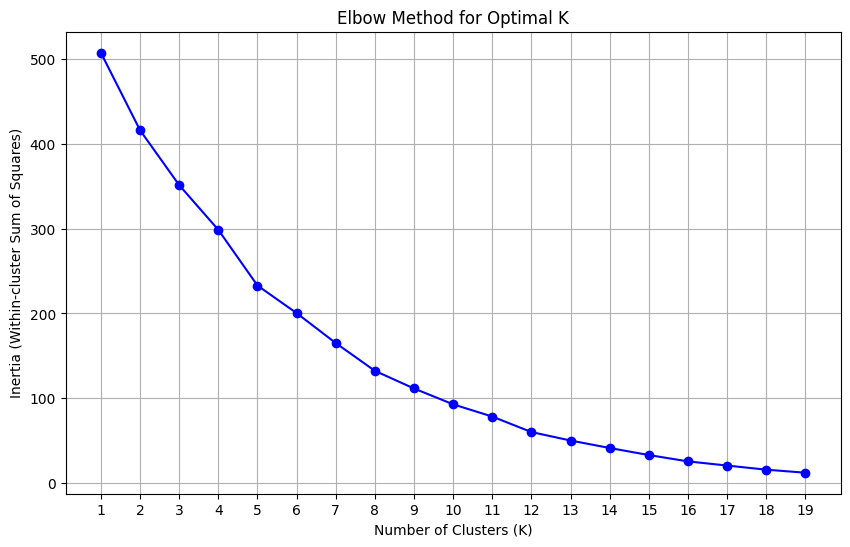

In [278]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Scaling ข้อมูล (สำคัญมากสำหรับ K-Means เพราะใช้ระยะห่างทางเรขาคณิต)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(features_df)

# 2. คำนวณ Inertia สำหรับค่า K ต่างๆ
inertia = []
k_range = range(1, 20)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

# 3. วาดกราฟ Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-cluster Sum of Squares)')
plt.title('Elbow Method for Optimal K')
plt.xticks(k_range)
plt.grid(True)
plt.show()

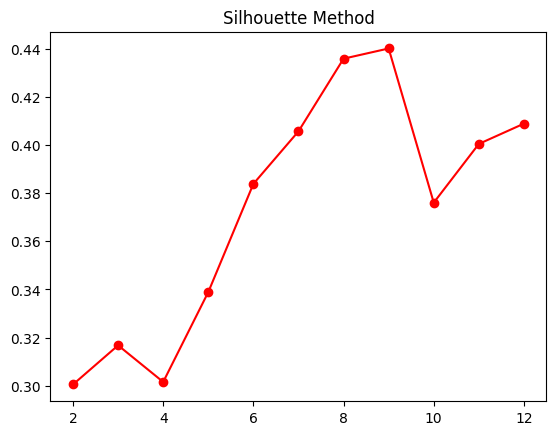

In [279]:
from sklearn.metrics import silhouette_score

# เพิ่มโค้ดส่วนนี้หลังรัน Loop K-Means
sil_scores = []
for k in range(2, 13): # Silhouette เริ่มที่ k=2
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(scaled_data)
    sil_scores.append(silhouette_score(scaled_data, labels))

# พล็อต Silhouette Score (ค่าสูงสุดคือดีที่สุด)
plt.plot(range(2, 13), sil_scores, 'ro-')
plt.title('Silhouette Method')
plt.show()

In [280]:
# สมมติว่าจากกราฟเลือก K = 4
optimal_k = 9

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(scaled_data)

# ใส่ผลลัพธ์กลับเข้าไปใน DataFrame เดิมเพื่อดูว่าพรรคไหนอยู่กลุ่มไหน
features_df['cluster'] = clusters

# ดูผลลัพธ์เบื้องต้น
print(f"จำนวนสมาชิกในแต่ละ Cluster:\n{features_df['cluster'].value_counts()}")

จำนวนสมาชิกในแต่ละ Cluster:
cluster
1    20
0     6
5     3
6     2
7     2
8     2
3     2
4     1
2     1
Name: count, dtype: int64


C:\Users\User\AppData\Local\Temp\ipykernel_27164\2951842720.py:8: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [281]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import plotly.express as px

# 1. ทำ Dimensionality Reduction เป็น 3 มิติ
# สมมติว่า scaled_data คือข้อมูลที่ผ่าน StandardScaler มาแล้ว
pca = PCA(n_components=3)
pca_results = pca.fit_transform(scaled_data)

# 2. สร้าง DataFrame สำหรับการทำ Visualization
viz_df = pd.DataFrame(
    data=pca_results, 
    columns=['PC1', 'PC2', 'PC3'],
    index=features_df.index # ใช้ชื่อพรรคเป็น Index
)

# ใส่ผลลัพธ์ Cluster กลับเข้าไป
viz_df['Cluster'] = features_df['cluster'].astype(str) # แปลงเป็น string เพื่อให้สีแยกกันชัดเจน
viz_df['Party'] = features_df.index

# 3. วาดกราฟ 3D ด้วย Plotly
fig = px.scatter_3d(
    viz_df, 
    x='PC1', 
    y='PC2', 
    z='PC3',
    color='Cluster',
    text='Party', # แสดงชื่อพรรคเมื่อเอาเมาส์ไปชี้
    title='3D Visualization of Political Party Clusters',
    labels={'PC1': 'Principal Component 1', 
            'PC2': 'Principal Component 2', 
            'PC3': 'Principal Component 3'},
    opacity=0.8
)

# ปรับแต่งขนาดและ Layout
fig.update_layout(margin=dict(l=0, r=0, b=0, t=40))
fig.show()

# 4. แถม: เช็คว่า 3 แกนนี้อธิบายข้อมูลได้กี่เปอร์เซ็นต์
explained_variance = pca.explained_variance_ratio_.sum() * 100
print(f"3 แกนใหม่นี้สามารถอธิบายความต่างของข้อมูลได้ทั้งหมด: {explained_variance:.2f}%")

3 แกนใหม่นี้สามารถอธิบายความต่างของข้อมูลได้ทั้งหมด: 51.53%


In [282]:
viz_df

,PC1,PC2,PC3,Cluster,Party
voter_party,,,,,
กล้าธรรม,0.668731,0.787330,0.409700,5,กล้าธรรม
ครูไทยเพื่อประชาชน,0.297557,1.497525,-0.148541,5,ครูไทยเพื่อประชาชน
ชาติพัฒนา,-0.954259,0.317070,-0.236061,1,ชาติพัฒนา
ชาติไทยพัฒนา,2.375019,-0.275275,-0.968475,5,ชาติไทยพัฒนา
ท้องที่ไทย,-1.179379,0.638172,-0.647294,6,ท้องที่ไทย
ประชาชน,2.062268,-0.533837,-0.464070,0,ประชาชน
ประชาชาติ,4.250265,-3.042000,-1.945874,0,ประชาชาติ
ประชาธรรมไทย,-1.190470,0.461099,-0.085196,1,ประชาธรรมไทย
ประชาธิปัตย์,1.676518,-1.342508,-0.218437,0,ประชาธิปัตย์


In [153]:
# 1. Scale ข้อมูลก่อน (ตัด cluster ออกถ้ามี)
X_input = features_df.drop(columns=['cluster'], errors='ignore')
X_scaled = scaler.fit_transform(X_input)

# 2. สร้าง viz_df จากข้อมูลที่ Scale แล้ว
viz_df = pd.DataFrame(
    data=X_scaled, 
    columns=X_input.columns,
    index=features_df.index
)

# 3. ใส่ cluster กลับเข้าไปเพื่อใช้จำแนกสี
viz_df['cluster'] = features_df['cluster']

# 1. ดึงชื่อพรรคจาก Index ออกมาเป็นคอลัมน์ 'voter_party' เพื่อให้ Plotly เรียกใช้ได้
plot_df = viz_df.reset_index()

# 2. วาดกราฟโดยระบุชื่อคอลัมน์ให้ตรงเป๊ะ (Case-sensitive)
fig = px.scatter_3d(
    plot_df, 
    x=plot_df.columns[1], # แกน X (Feature แรก)
    y=plot_df.columns[2], # แกน Y (Feature ที่สอง)
    z=plot_df.columns[3], # แกน Z (Feature ที่สาม)
    color='cluster',      # ใช้ 'cluster' ตัวเล็กตามที่ตั้งไว้ในขั้นตอนที่ 3
    text='voter_party',   # ใช้ชื่อคอลัมน์ที่ได้จากการ reset_index()
    title='3D Visualization of Political Party Clusters',
    labels={
        plot_df.columns[1]: str(plot_df.columns[1]), 
        plot_df.columns[2]: str(plot_df.columns[2]), 
        plot_df.columns[3]: str(plot_df.columns[3])
    },
    opacity=0.8
)

# ปรับแต่ง Layout
fig.update_layout(margin=dict(l=0, r=0, b=0, t=40))
fig.show()

In [154]:
plot_df

,voter_party,ENACTED,avg_entropy_bits,avg_absence_rate,cluster
0,กล้าธรรม,-0.251959,0.072410,0.187331,1
1,ครูไทยเพื่อประชาชน,-0.251959,-0.781260,0.541804,3
2,ชาติพัฒนา,-0.251959,-0.240764,-1.076196,0
3,ชาติไทยพัฒนา,-0.251959,0.236856,0.264642,1
4,ท้องที่ไทย,-0.251959,-0.781260,-0.699305,0
5,ประชาชน,-0.114376,-0.151285,-1.423757,0
6,ประชาชาติ,-0.251959,2.308156,0.401763,1
7,ประชาธรรมไทย,-0.251959,-0.781260,-1.033862,0
8,ประชาธิปัตย์,0.066090,0.940590,-0.257847,1
9,ประชาธิปไตยใหม่,-0.251959,0.016634,-0.068765,0


In [180]:
viz_export = viz_df.drop(columns='Party')
viz_export

,PC1,PC2,PC3,Cluster
voter_party,,,,
กล้าธรรม,0.668731,0.787330,0.409700,5
ครูไทยเพื่อประชาชน,0.297557,1.497525,-0.148541,5
ชาติพัฒนา,-0.954259,0.317070,-0.236061,1
ชาติไทยพัฒนา,2.375019,-0.275275,-0.968475,5
ท้องที่ไทย,-1.179379,0.638172,-0.647294,6
ประชาชน,2.062268,-0.533837,-0.464070,0
ประชาชาติ,4.250265,-3.042000,-1.945874,0
ประชาธรรมไทย,-1.190470,0.461099,-0.085196,1
ประชาธิปัตย์,1.676518,-1.342508,-0.218437,0


In [179]:
viz_export.to_csv('viz_result.csv')

In [129]:
print(pca.components_.shape[1])
original_features = [col for col in features_df.columns if col != 'cluster']
print(len(original_features))

13
13


In [283]:
# ดูน้ำหนักของ Feature ในแต่ละแกน (Loadings)
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=['PC1', 'PC2', 'PC3'], 
    index=features_df.drop(columns=['cluster']).columns # รายชื่อ Feature เดิม
)

# ดู Top 3 Features ที่ส่งผลต่อแต่ละแกนมากที่สุด
for col in loadings.columns:
    print(f"--- Top Features for {col} ---")
    print(loadings[col].sort_values(ascending=False).head(3))
    print("\n")

--- Top Features for PC1 ---
สิ่งแวดล้อม          0.443943
กระบวนการยุติธรรม    0.439957
avg_entropy_bits     0.358996
Name: PC1, dtype: float64


--- Top Features for PC2 ---
แรงงาน      0.448547
ENACTED     0.429033
การศึกษา    0.193816
Name: PC2, dtype: float64


--- Top Features for PC3 ---
อื่นๆ        0.576185
สาธารณสุข    0.548603
แรงงาน       0.312211
Name: PC3, dtype: float64




In [132]:
import plotly.graph_objects as go

# สร้างกราฟพื้นฐาน (จุดของแต่ละพรรค)
fig = px.scatter_3d(viz_df, x='PC1', y='PC2', z='PC3', color='Cluster', text='Party', opacity=0.5)

# เพิ่มลูกศร (Vectors) บ่งบอกความหมายของ Feature (Loadings)
# เราจะเลือกเฉพาะ Feature สำคัญๆ มาโชว์เพื่อไม่ให้รกเกินไป
top_features = loadings.abs().sum(axis=1).sort_values(ascending=False).head(5).index

for feature in top_features:
    fig.add_trace(go.Scatter3d(
        x=[0, loadings.loc[feature, 'PC1'] * 5], # คูณ 5 เพื่อให้ลูกศรยาวขึ้นจนเห็นชัด
        y=[0, loadings.loc[feature, 'PC2'] * 5],
        z=[0, loadings.loc[feature, 'PC3'] * 5],
        mode='lines+text',
        name=feature,
        text=[None, feature],
        line=dict(color='black', width=4)
    ))

fig.update_layout(title="3D Political Biplot: พฤติกรรมพรรคการเมืองและแกนความหมาย")
fig.show()

# Collecting all data

In [284]:
unity_df = pd.read_csv('unity.csv')
unity_df.drop(columns='Unnamed: 0', inplace=True)
unity_df

,voter_party,vote_events,avg_present_votes,avg_unity_score,avg_unity_pct
0,ครูไทยเพื่อประชาชน,138,1.00,1.0000,100.00
1,ประชาธรรมไทย,76,1.00,1.0000,100.00
2,ท้องที่ไทย,37,1.00,1.0000,100.00
3,พลังไทยรักไทย,6,1.00,1.0000,100.00
4,พลังธรรมใหม่,146,1.00,1.0000,100.00
5,พลังชาติไทย,113,1.00,1.0000,100.00
6,พรร่คภูมีใจไทย,2,1.00,1.0000,100.00
7,ประชาภิวัฒน์,146,1.00,1.0000,100.00
8,ประชานิยม,2,1.00,1.0000,100.00
9,ใหม่,45,1.00,1.0000,100.00


In [285]:
viz_df.drop(columns='Party', inplace=True)

In [288]:
viz_df

,PC1,PC2,PC3,Cluster
voter_party,,,,
กล้าธรรม,0.668731,0.787330,0.409700,5
ครูไทยเพื่อประชาชน,0.297557,1.497525,-0.148541,5
ชาติพัฒนา,-0.954259,0.317070,-0.236061,1
ชาติไทยพัฒนา,2.375019,-0.275275,-0.968475,5
ท้องที่ไทย,-1.179379,0.638172,-0.647294,6
ประชาชน,2.062268,-0.533837,-0.464070,0
ประชาชาติ,4.250265,-3.042000,-1.945874,0
ประชาธรรมไทย,-1.190470,0.461099,-0.085196,1
ประชาธิปัตย์,1.676518,-1.342508,-0.218437,0


In [297]:
# 1. หาค่าสัดส่วนสูงสุด (Max Proportion) ของแต่ละพรรค
max_props = one_df.groupby('party_cleaned')['proportion'].transform('max')

# 2. กรองเอาเฉพาะแถวที่มีสัดส่วนเท่ากับค่า Max นั้น
top_categories = one_df[one_df['proportion'] == max_props].copy()

# 3. รวมชื่อหมวดหมู่ที่ซ้ำกันในพรรคเดียวให้กลายเป็น String เดียว (เช่น 'เศรษฐกิจ/การเมือง')
bill_types = top_categories.groupby('party_cleaned')['categories'].apply(lambda x: '/'.join(x)).reset_index()

# 4. เปลี่ยนชื่อคอลัมน์เพื่อเตรียม Merge
bill_types = bill_types.rename(columns={'party_cleaned': 'voter_party', 'categories': 'bill_types'})

# ล้างชื่อพรรคเผื่อไว้ (Standardize)
bill_types['voter_party'] = bill_types['voter_party'].str.replace('พรรค', '', regex=False).str.strip()

print(bill_types)

           voter_party                          bill_types
0             กล้าธรรม                           สวัสดิการ
1   ครูไทยเพื่อประชาชน                           สวัสดิการ
2         ชาติไทยพัฒนา                            การศึกษา
3           ท้องที่ไทย                            การเมือง
4              ประชาชน                            การเมือง
5            ประชาชาติ                         สิ่งแวดล้อม
6         ประชาธิปัตย์                            เศรษฐกิจ
7      ประชาธิปไตยใหม่                            เศรษฐกิจ
8       พลังท้องถิ่นไท                            เศรษฐกิจ
9         พลังธรรมใหม่                            การเมือง
10        พลังประชารัฐ                            เศรษฐกิจ
11           ภูมิใจไทย                            เศรษฐกิจ
12     รวมไทยสร้างชาติ                            เศรษฐกิจ
13            เป็นธรรม                     สาธารณสุข/อื่นๆ
14            เพื่อไทย                            เศรษฐกิจ
15            เศรษฐกิจ  การศึกษา/สวัสดิการ/เศรษฐกิจ/แรงง

In [298]:
# # 1. bill_types: ดึงหมวดหมู่ที่พรรคเสนอบ่อยที่สุด (Top Category)
# bill_types = one_df.sort_values(['party_cleaned', 'proportion'], ascending=[True, False]) \
#                    .groupby('party_cleaned').head(1) \
#                    .rename(columns={'party_cleaned': 'voter_party', 'categories': 'bill_types'})[['voter_party', 'bill_types']]

# 2. unity: ดึงค่าเฉลี่ยความสามัคคี
unity = unity_df[['voter_party', 'avg_unity_score']].rename(columns={'avg_unity_score': 'unity'})

# 3. success_rate: ดึงเฉพาะสถานะที่ 'สำเร็จ' (สมมติว่าเป็น MERGED หรือ ENACTED)
# หรือถ้าเอาตามที่คุณต้องการคือค่า Success รวม ผมแนะนำให้ดึงตัวที่สูงสุดหรือรวมสถานะบวกครับ
# ในที่นี้ขอดึงตัวที่บ่งบอกความสำเร็จ (เช่น MERGED/ENACTED) ถ้าไม่มีให้เป็น 0
success = four_df[four_df['status'].isin(['MERGED', 'ENACTED', 'PUBLISHED'])] \
                 .groupby('party_cleaned')['proportion'].sum().reset_index() \
                 .rename(columns={'party_cleaned': 'voter_party', 'proportion': 'success_rate'})

# 4. attendance_rate: คำนวณจาก (1 - absence_rate)
attendance = five.copy()
attendance['attendance_rate'] = 1 - attendance['avg_absence_rate']
attendance = attendance[['voter_party', 'attendance_rate']]

In [299]:
def clean_party_name(df, col_name):
    if col_name in df.columns:
        df[col_name] = df[col_name].astype(str).str.replace('พรรค', '', regex=False).str.strip()
    return df

In [300]:
bill_types = clean_party_name(bill_types, "voter_party")
bill_types

,voter_party,bill_types
0,กล้าธรรม,สวัสดิการ
1,ครูไทยเพื่อประชาชน,สวัสดิการ
2,ชาติไทยพัฒนา,การศึกษา
3,ท้องที่ไทย,การเมือง
4,ประชาชน,การเมือง
5,ประชาชาติ,สิ่งแวดล้อม
6,ประชาธิปัตย์,เศรษฐกิจ
7,ประชาธิปไตยใหม่,เศรษฐกิจ
8,พลังท้องถิ่นไท,เศรษฐกิจ
9,พลังธรรมใหม่,การเมือง


In [302]:
# เริ่มจาก pca_df ที่คุณมี PC1, PC2, PC3, Cluster อยู่แล้ว
final_summary = viz_df.reset_index()

# Merge ทีละส่วนเข้ามา
final_summary = final_summary.merge(bill_types, on='voter_party', how='left')
final_summary = final_summary.merge(unity, on='voter_party', how='left')
final_summary = final_summary.merge(success, on='voter_party', how='left')
final_summary = final_summary.merge(attendance, on='voter_party', how='left')

# เติมค่าว่างสำหรับพรรคที่ไม่มีข้อมูลบางส่วน
final_summary['success_rate'] = final_summary['success_rate'].fillna(0)
final_summary = final_summary.fillna('N/A') # สำหรับ bill_types ที่ไม่มีข้อมูล

# จัดเรียง Column ตามที่คุณต้องการ
column_order = ['voter_party', 'PC1', 'PC2', 'PC3', 'Cluster', 'bill_types', 'unity', 'success_rate', 'attendance_rate']
final_summary = final_summary[column_order]

# แสดงผล 5 แถวแรก
print(final_summary)

             voter_party       PC1       PC2       PC3 Cluster  \
0               กล้าธรรม  0.668731  0.787330  0.409700       5   
1     ครูไทยเพื่อประชาชน  0.297557  1.497525 -0.148541       5   
2              ชาติพัฒนา -0.954259  0.317070 -0.236061       1   
3           ชาติไทยพัฒนา  2.375019 -0.275275 -0.968475       5   
4             ท้องที่ไทย -1.179379  0.638172 -0.647294       6   
5                ประชาชน  2.062268 -0.533837 -0.464070       0   
6              ประชาชาติ  4.250265 -3.042000 -1.945874       0   
7           ประชาธรรมไทย -1.190470  0.461099 -0.085196       1   
8           ประชาธิปัตย์  1.676518 -1.342508 -0.218437       0   
9        ประชาธิปไตยใหม่  0.157930 -0.499646 -0.188666       7   
10             ประชานิยม -1.102786  0.516883 -0.126352       1   
11          ประชาภิวัฒน์ -1.348293  0.360691 -0.011120       1   
12           พลังชาติไทย -1.349186  0.360123 -0.010701       1   
13        พลังท้องถิ่นไท  0.141300 -0.684089 -1.199873       8   
14        

In [ ]:
final_summary.to_csv('final_summary.csv')